![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

W zeszycie przedstawiono empiryczną prezentację podstawowych twierdzeń granicznych

In [1]:
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
%matplotlib inline

**tw. graniczne Moivre-Laplace**

Niech ${X_n}$ będzie ciągiem zmiennych losowych o rozkładzie dwumianowym
$$P(X_n=k)={n\choose k}p^k(1-p)^{n-k}$$
którego wartość oczkiwana $E[X_n]=n\cdot p$ i wariancja $V[X_n]=n\cdot p\cdot (1-p)$ 
Jeśli ciąg dystrybuant ${F_n(y)}$ jest ciagiem dystrybuant zmiennej losowej $$Y_n=\frac{X_n-n\cdot p}{\sqrt{n\cdot p\cdot q}}$$
wówczas $$\lim_{n\to+\infty}F_n(y)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^y e^{-\frac{1}{2}u^2} du$$

Twierdzenie to oznacza, że jeśli losujemy wiele wartości z rozkładu dwumianowego (zadanie na określanie proporcji) to stadaryzowana średnia tej proporcji podlega standaryzowanemu rozkładowi normalnemu $N(0,1)$

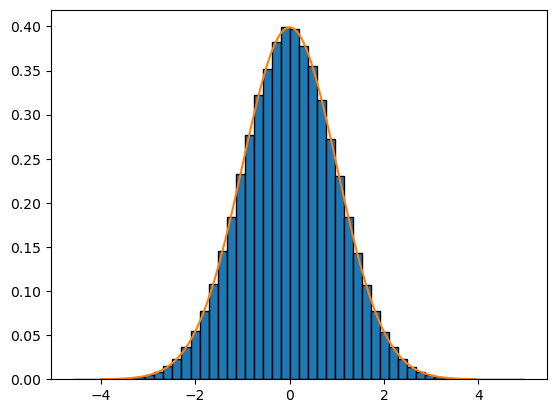

In [2]:
p = 0.25
n = 1000000 # rozmiar próby
BinomialDistribution = st.binom(n,p)
X = BinomialDistribution.rvs(n)
Y = (X - n*p)/(n*p*(1-p))**0.5

plt.hist(Y,bins=50,density=True,edgecolor='black')
NormalDistribution = st.norm(0,1)
x = np.arange(-4,4,0.05)
plt.plot(x,NormalDistribution.pdf(x))
pass

**Centralne twierdzenie graniczne**

Jeśli ${X_n}$ jest ciągiem niezależnych identycznych zmiennych losowych ze skończoną wartością oczekiwaną $\mu$ i skończoną wariancją $\sigma^2$ większą od zera to ciąg dystrybuanty ${F_n(z)}$ zmiennej losowej $$Z_n=\frac{\sum_{i=1}^nX_i - n \cdot \mu}{\sigma \cdot \sqrt{n}}$$ jest zbieżny do $$\lim_{n\to+\infty}F_n(y)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^y e^{-\frac{1}{2}u^2} du$$

Tw. to oznacza, że średnia arytmetyczna z prób z dowolnego rozkładu (przy odpowiednio dużej próbie) podlega rozkładowi normalnemu $N(0,1)$

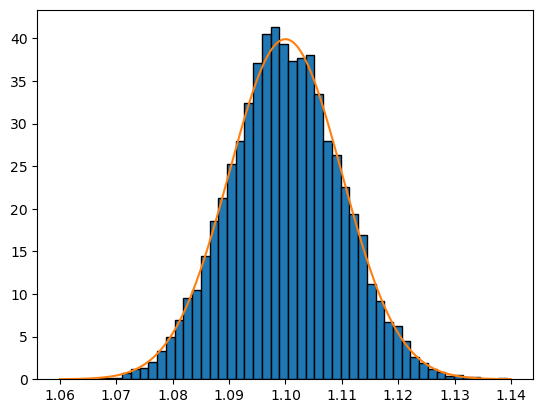

In [3]:
N= 10000
n = 10000 # rozmiar próby
U = np.zeros((N,)) # liczba próbek

SomeDistribution = st.expon(1/10) #użyj dowolnego rozkładu
m = SomeDistribution.mean()
s = SomeDistribution.std()

for i in range(N):
    X = SomeDistribution.rvs(n)
    U[i] = np.mean(X)

plt.hist(U,bins=50,density=True,edgecolor='black')
S = s/n**0.5
NormalDistribution = st.norm(m,S)
x = np.arange(m-4*S,m+4*S,0.01*S)
plt.plot(x,NormalDistribution.pdf(x))
pass

**Twierdzenie Czebyszewa**

Jeśli (dowolna) zmienna losowa $X$ ma skończoną wartość oczekiwaną $\mu$ oraz wariancję $\sigma^2$, wówczas dla dowolnej dodatniej liczby $\epsilon$ zachodzi $$P \left ( |X-\mu|\geq \epsilon \right ) \leq \frac{\sigma^2}{\epsilon^2}$$

Twierdzenie to pozwala oszacować prawdopodobieństwo zdarzenia polegającego na tym, że zmienna losowa przyjmie wartość różniącą się od średniej (wartości oczekiwanej rozkładu) więcej niż o $\epsilon$. Prawdopodobieństwo to jest mniejsze lub równe $\frac{\sigma^2}{\epsilon^2}$

Poniżej przedstawiono oszacowanie za pomocą tw. Czebyszewa i wartość dokładną. Wykorzystano przekształcone tw. w postaci:

$$P \left ( |X-\mu| < k\cdot \sigma \right ) \geq 1-\frac{1}{k^2}$$

gdzie k jest dowolną liczba dodatnią większą lub równą 1

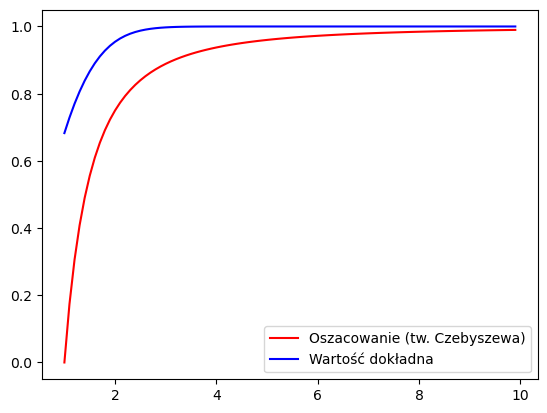

In [4]:
ProbabilityDistribution = st.norm(0,1) # wybierz dowolny rozkład
#ProbabilityDistribution = st.expon()
m = ProbabilityDistribution.mean()
s = ProbabilityDistribution.std()

k = np.arange(1,10,0.1)
Pcheb = 1-1/k**2
Pexact = ProbabilityDistribution.cdf(m+k*s)- ProbabilityDistribution.cdf(m-k*s)
plt.plot(k,Pcheb,"red",k,Pexact,"blue")
plt.legend(["Oszacowanie (tw. Czebyszewa)", "Wartość dokładna"])
pass

**Twierdzenie Chińczyna**

Jeśli ${X_n}$ jest ciągiem niezależnych identycznych zmiennych losowych posiadających skończoną wartość oczkiwaną $E[X_n]=\mu$, wówczas ciąg zmiennych losowych $$Y_n=\frac{\sum_{i=1}^n X_i}{n}$$ jest stochastycznie zbieżny do do stałej $\mu$, tzn.:
$$\lim_{n\to\infty}P(|Y_n-\mu|\geq \epsilon)=0$$

Twierdzenie to oznacza, że wraz ze wzrostem liczebności próby wartość średnia z próby staje się coraz bliższa wartości średniej populacji generalnej.

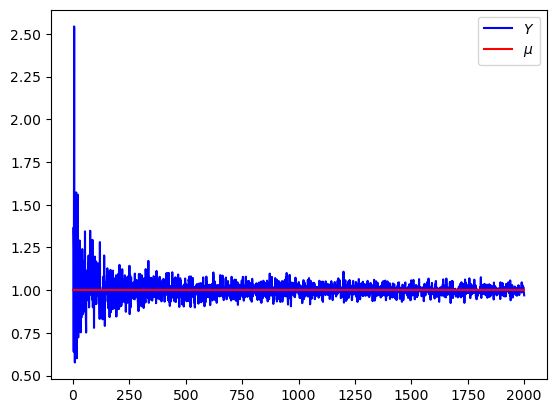

In [5]:
#ProbabilityDistribution = st.norm(3,1) 
ProbabilityDistribution = st.expon() # wybierz dowolny rozkład

m = ProbabilityDistribution.mean()
N = 2000
Y = np.zeros(N)
for n in range(N):
    Y[n] = np.mean(ProbabilityDistribution.rvs(n+1))
    
plt.plot(np.array(range(1,N+1)),Y,"blue",[1,N],[m,m],"red")
plt.legend(["$Y$","$\mu$"])
pass